In [12]:
import pandas as pd
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
raw_df = pd.read_csv("enriched_call_log.csv", sep=";", header=0)
print(raw_df.columns)
print(raw_df.dtypes)
phone_df = raw_df[[
    "ActivityDate"
    ,"CallDurationInSeconds"
    ,"IsClosed"
    ,"IsHighPriority"
    ,"IsRecurrence"
    ,"IsReminderSet"
    ,"IsVisibleInSelfService"
    ,"Benefit_Program_Employee__c"
    ,"Benefit_Program_Equinor__c"
    ,"Benefit_Program_Finans__c"
    ,"Benefit_Program_Hydro__c"
    ,"Benefit_Program_If_insurance_NUF__c"
    ,"Benefit_Program_NHO__c"
    ,"Benefit_Program_NRK__c"
    ,"Benefit_Program_PBL__c"
    ,"Benefit_Program_Reserved__c"
    ,"Benefit_Program_Skagen__c"
    ,"Benefit_Program_Skagen_Employees__c"
    ,"Benefit_Program_Special__c"
    ,"Benefit_Program_Storebrand_Employees__c"
    ,"NumberOfEmployees"
    ,"NACE_Industry_Name__c"
    ,"Organization_Average_Salary__c"
    ,"Organization_Registered_Date__c"
    ,"Organization_Number__c"
    ,"Organization_Official_Name__c"
    ,"Organization_Salary_Costs__c"
    ,"Organization_Type__c"
]]
phone_df["ActivityDate"] = pd.to_datetime(phone_df[~phone_df["ActivityDate"].isna()]["ActivityDate"], format="mixed")
phone_df = phone_df[phone_df["ActivityDate"] >= datetime(2024, 5, 1)]
phone_df["CompanyAgeInYears"] = (datetime.today() - pd.to_datetime(phone_df["Organization_Registered_Date__c"]))
phone_df["CompanyAgeInYears"] = phone_df["CompanyAgeInYears"].apply(lambda d: d.total_seconds() / 60 / 60 / 24 / 365.25)

Index(['AccountId', 'ActivityDate', 'Call_Duration_converted__c',
       'Call_Result__c', 'Call_Type__c', 'CallDurationInSeconds', 'CallType',
       'CompletedDateTime', 'Id', 'Is_Manager_And_Above__c', 'IsArchived',
       'IsClosed', 'IsDeleted', 'IsHighPriority', 'IsRecurrence',
       'IsReminderSet', 'IsReminderSet__c', 'IsVisibleInSelfService',
       'Owner_Phone__c', 'OwnerId', 'Phone__c', 'Priority',
       'Account_Status__c', 'AccountNumber', 'AccountSource', 'AnnualRevenue',
       'Asset_Management_Customer__pc',
       'Asset_Management_Customer_Formula__pc', 'Assumed_Employer__c',
       'Benefit_Program_Employee__c', 'Benefit_Program_Equinor__c',
       'Benefit_Program_Finans__c', 'Benefit_Program_Hydro__c',
       'Benefit_Program_If_insurance_NUF__c', 'Benefit_Program_NHO__c',
       'Benefit_Program_NRK__c', 'Benefit_Program_PBL__c',
       'Benefit_Program_Reserved__c', 'Benefit_Program_Skagen__c',
       'Benefit_Program_Skagen_Employees__c', 'Benefit_Program_Sp

C:\Users\YYP\AppData\Local\Temp\ipykernel_25032\1050171988.py:1: DtypeWarning: Columns (0,3,22,24,27,28,42,43,44,49,50,51,52,53,54,55,56,59,60,63,65,66,67,69,70,71,72) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv("enriched_call_log.csv", sep=";", header=0)
C:\Users\YYP\AppData\Local\Temp\ipykernel_25032\1050171988.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phone_df["ActivityDate"] = pd.to_datetime(phone_df[~phone_df["ActivityDate"].isna()]["ActivityDate"], format="mixed")


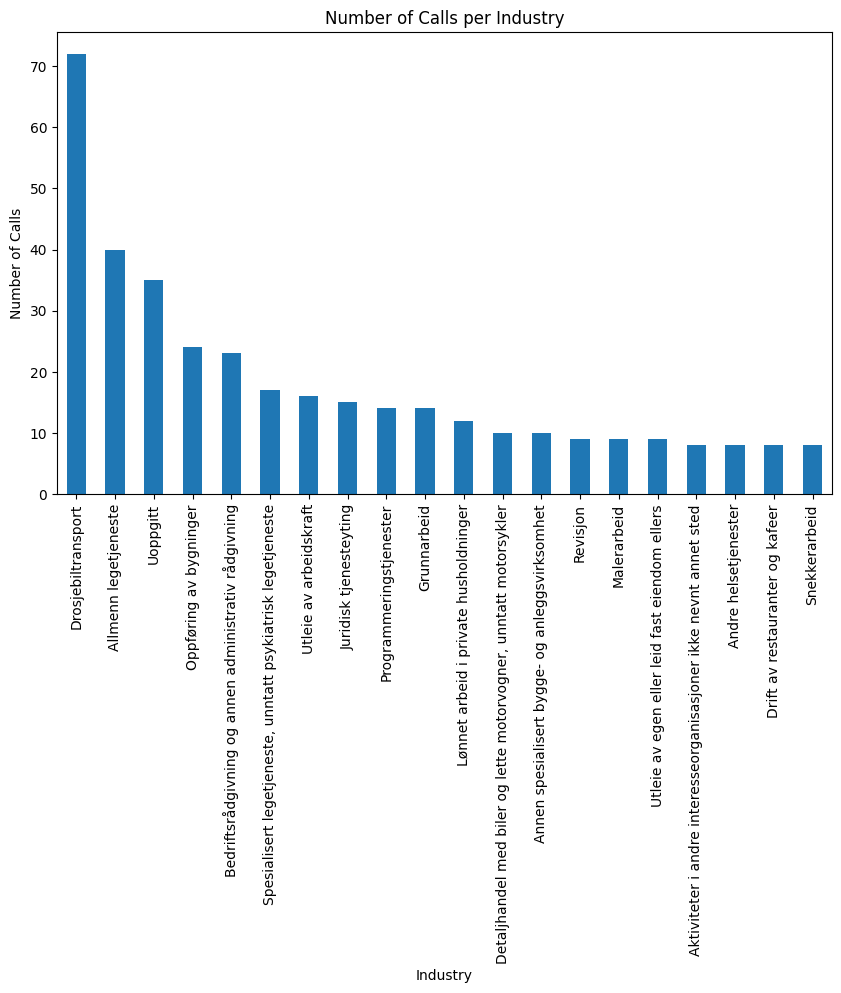

In [32]:
industry_calls = phone_df['NACE_Industry_Name__c'].value_counts().nlargest(20)
plt.figure(figsize=(10, 6))
industry_calls.plot(kind='bar')
plt.title('Number of Calls per Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Calls')
plt.show()

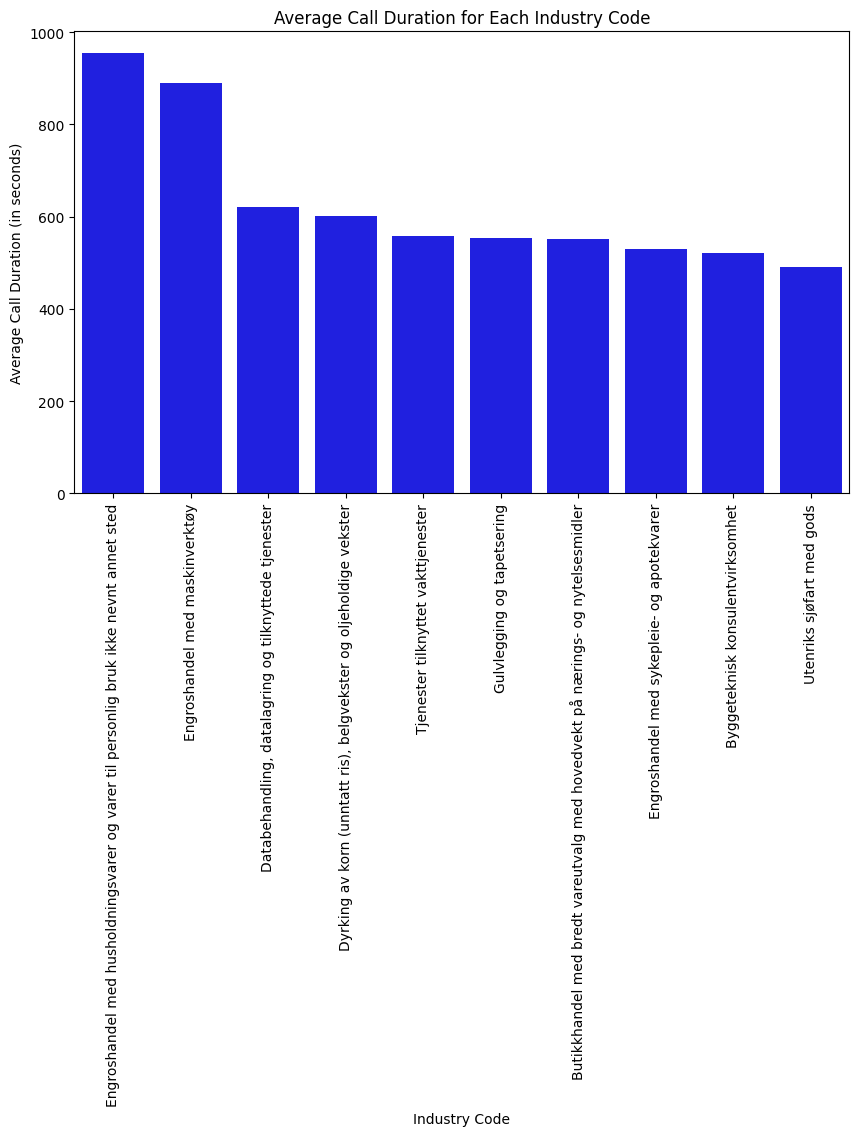

In [14]:
# Visualize the average call duration for each industry code
avg_call_duration = phone_df.groupby("NACE_Industry_Name__c")["CallDurationInSeconds"].mean()
avg_call_duration = avg_call_duration.nlargest(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_call_duration.index, y=avg_call_duration.values, color='b')
plt.title("Average Call Duration for Each Industry Code")
plt.xlabel("Industry Code")
plt.xticks(rotation=90)
plt.ylabel("Average Call Duration (in seconds)")
plt.show()

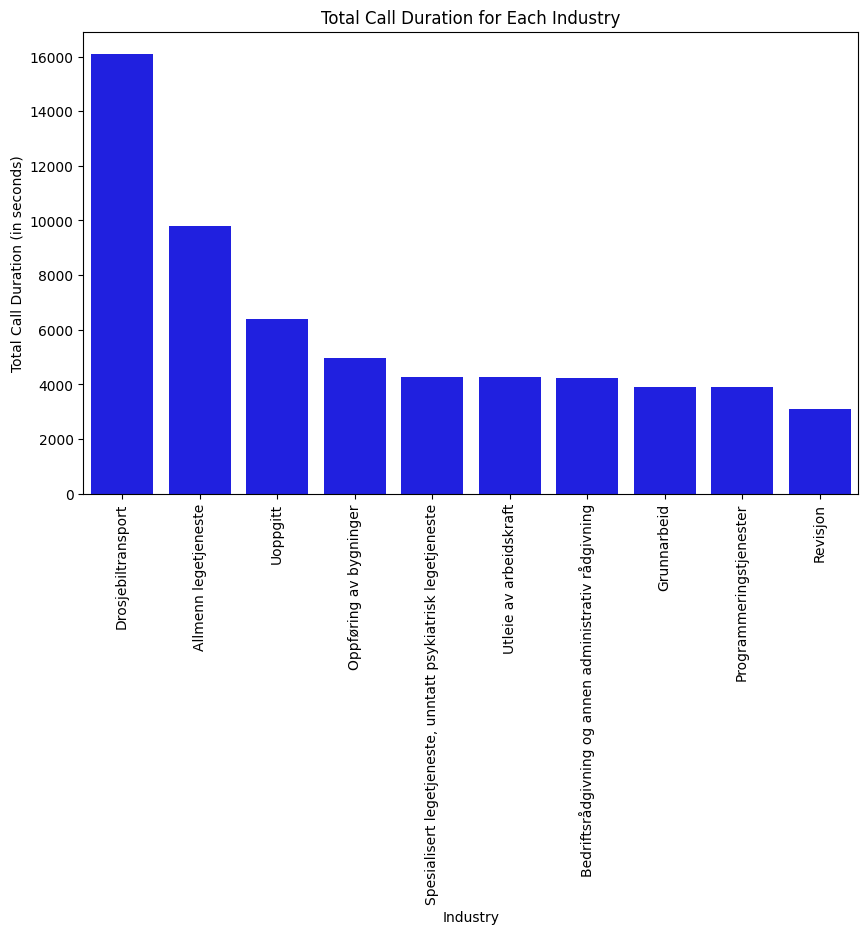

In [15]:
# Total time spent on each industry code
total_call_duration = phone_df.groupby("NACE_Industry_Name__c")["CallDurationInSeconds"].sum()
top_10_industries = total_call_duration.nlargest(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_industries.index, y=top_10_industries.values, color='b')
plt.title("Total Call Duration for Each Industry")
plt.xlabel("Industry")
plt.xticks(rotation=90)
plt.ylabel("Total Call Duration (in seconds)")
plt.show()

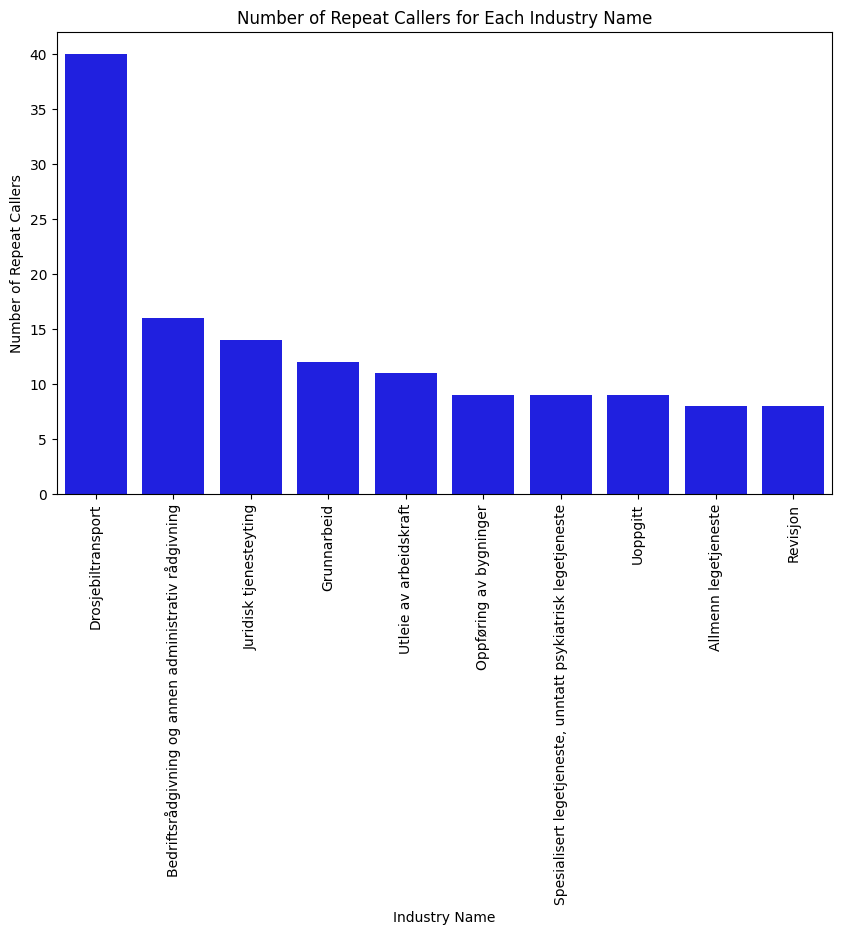

In [29]:
# repeat callers for each industry name
repeat_callers = phone_df[phone_df.duplicated(subset=['Organization_Number__c'], keep=False)].groupby('NACE_Industry_Name__c').size()
top_industries = repeat_callers.nlargest(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_industries.index, y=top_industries.values, color='b')
plt.title('Number of Repeat Callers for Each Industry Name')
plt.xlabel('Industry Name')
plt.xticks(rotation=90)
plt.ylabel('Number of Repeat Callers')
plt.show()

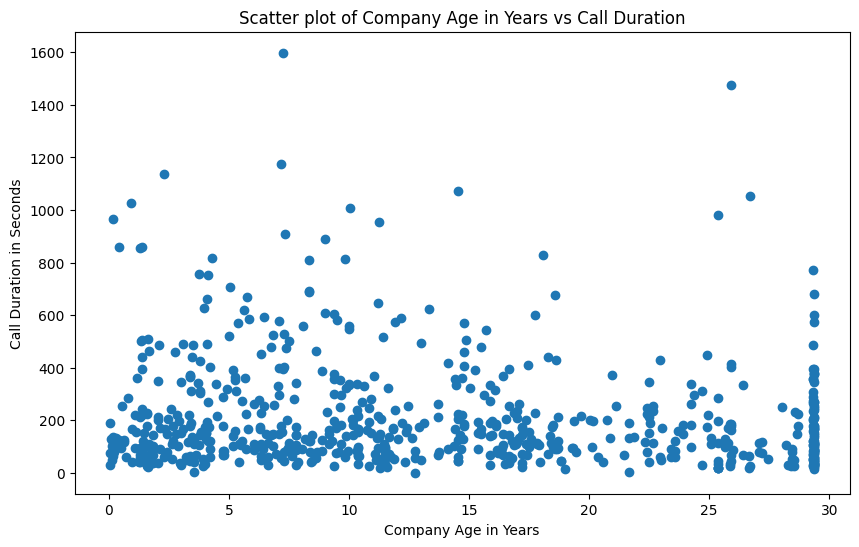

In [30]:
# correaltion between company age and call duration
plt.figure(figsize=(10, 6))
plt.scatter(phone_df['CompanyAgeInYears'], phone_df['CallDurationInSeconds'])
plt.title('Scatter plot of Company Age in Years vs Call Duration')
plt.xlabel('Company Age in Years')
plt.ylabel('Call Duration in Seconds')
plt.show()

Text(0, 0.5, 'Average Summed Duration (in seconds)')

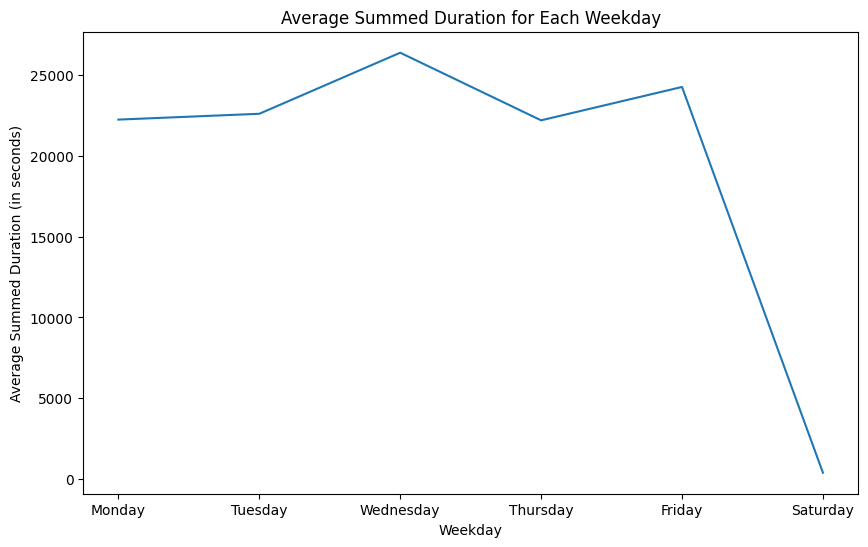

In [16]:
# See which days advisors receive calls
phone_df['ActivityDate'] = pd.to_datetime(phone_df['ActivityDate'])
phone_df['Weekday'] = phone_df['ActivityDate'].dt.day_name()
total_duration = phone_df.groupby('Weekday')['CallDurationInSeconds'].sum()
num_weeks = (phone_df['ActivityDate'].max() - phone_df['ActivityDate'].min()).days // 7
avg_summed_duration = total_duration / num_weeks
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_summed_duration = avg_summed_duration.reindex(weekdays)
plt.figure(figsize=(10, 6))
sns.lineplot(x=avg_summed_duration.index, y=avg_summed_duration.values)
plt.title('Average Summed Duration for Each Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average Summed Duration (in seconds)')

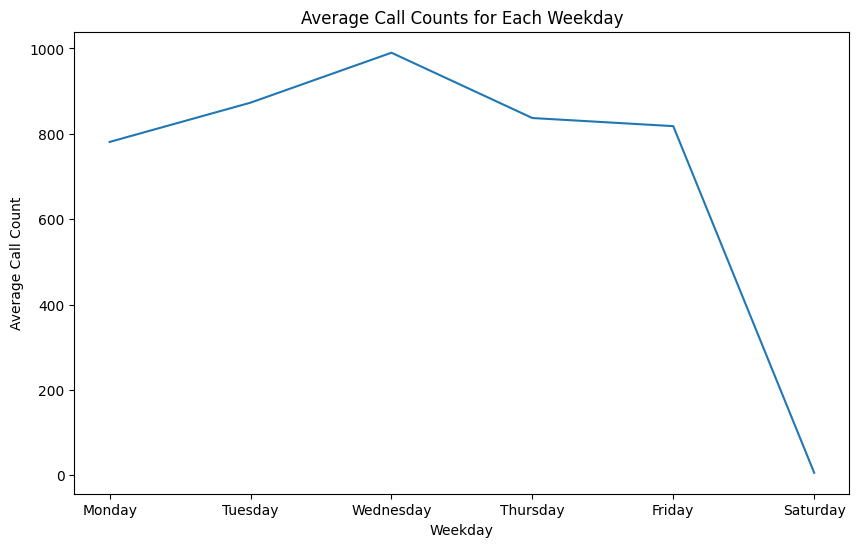

In [24]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
avg_call_counts = phone_df['Weekday'].value_counts().loc[order]
plt.figure(figsize=(10, 6))
sns.lineplot(x=avg_call_counts.index, y=avg_call_counts.values)
plt.title('Average Call Counts for Each Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average Call Count')
plt.show()

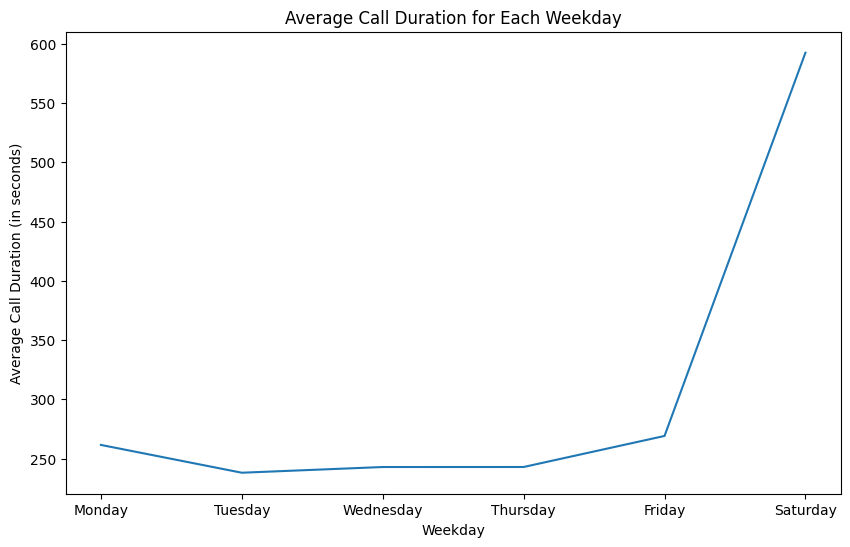

In [18]:
# average call duration throughout a typical week
phone_df['Weekday'] = pd.to_datetime(phone_df['ActivityDate']).dt.day_name()
avg_duration = phone_df.groupby('Weekday')['CallDurationInSeconds'].mean()
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_duration = avg_duration.reindex(weekdays)
plt.figure(figsize=(10, 6))
sns.lineplot(x=avg_duration.index, y=avg_duration.values)
plt.title('Average Call Duration for Each Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average Call Duration (in seconds)')
plt.show()

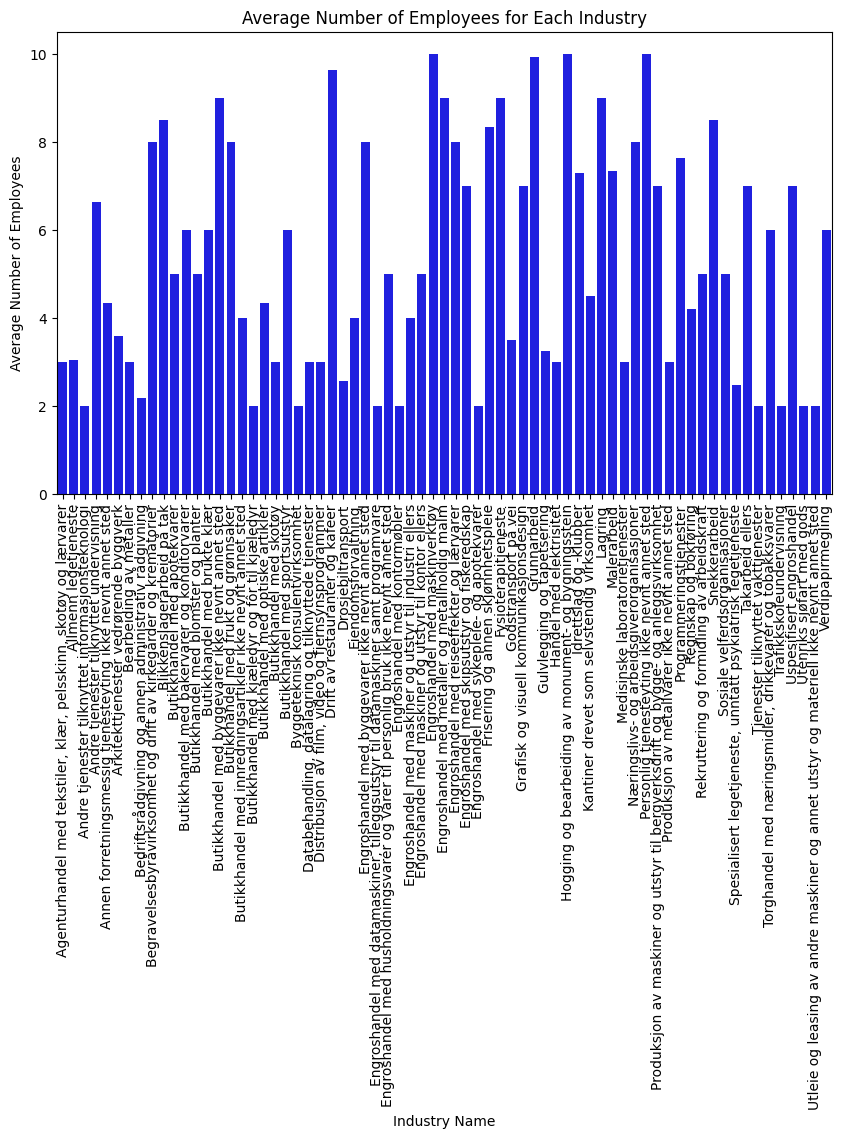

NACE_Industry_Name__c
Agenturhandel med tekstiler, klær, pelsskinn, skotøy og lærvarer                          3.000000
Allmenn legetjeneste                                                                      3.050000
Andre tjenester tilknyttet informasjonsteknologi                                          2.000000
Andre tjenester tilknyttet undervisning                                                   6.625000
Annen forretningsmessig tjenesteyting ikke nevnt annet sted                               4.333333
                                                                                            ...   
Trafikkskoleundervisning                                                                  2.000000
Uspesifisert engroshandel                                                                 7.000000
Utenriks sjøfart med gods                                                                 2.000000
Utleie og leasing av andre maskiner og annet utstyr og materiell ikke nevnt annet sted 

In [27]:
avg_num_employees = phone_df.groupby("NACE_Industry_Name__c")["NumberOfEmployees"].mean()
filtered_avg_num_employees = avg_num_employees[(avg_num_employees >= 2) & (avg_num_employees <= 10)]
plt.figure(figsize=(10, 6))
sns.barplot(x=filtered_avg_num_employees.index, y=filtered_avg_num_employees.values, color='b')
plt.title("Average Number of Employees for Each Industry")
plt.xlabel("Industry Name")
plt.xticks(rotation=90)
plt.ylabel("Average Number of Employees")
plt.show()
print(filtered_avg_num_employees)